In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from glob import glob
from tqdm import tqdm
import xarray as xr
import os, sys
import scipy
import pandas as pd
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from scipy import stats

from scipy import interpolate

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

from cinplaAnalysis.utils import *

%matplotlib inline

In [2]:
from cinplaAnalysis.icsd import StandardCSD, DeltaiCSD, StepiCSD

In [3]:
import matplotlib

font = {'size'   : 12}

matplotlib.rc('font', **font)

In [4]:
matplotlib.rcParams['savefig.pad_inches'] = 0

In [5]:
def plotFig(ax,csd,breaks=None,absmax=None,timeLimited=False,plotCB=False,xlabels=False,title=None):

    if breaks is not None:
        for b in breaks:
            ax.plot([0,3000],[b,b],c='k')

    if absmax is None:
        absmax = np.max(np.abs(csd))

    rms = np.mean(np.sqrt(csd**2))
    
    im = ax.imshow(np.array(csd)/rms, origin='lower',cmap='bwr_r',vmin=-10,vmax=10)#, vmin =-absmax,vmax=absmax, cmap='bwr_r')
    ax.axis(ax.axis('tight'))

    if plotCB:
        cb = plt.colorbar(im, ax=ax)
        cb.formatter.set_powerlimits((0,0))


    ax.set_yticklabels([])

    if xlabels:
        ax.set_xticks([0,50],labels=['0','50'])
        # ax.set_xlabel('Time (ms)')
    else:
        ax.set_xticklabels([])

    if timeLimited:
        ax.set_xlim([50,100])
    else:
        ax.set_xlim([0,50])

    if title:
        plt.title(title)

    plt.tight_layout()

In [6]:
def produce_iCSD(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = 0.376 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = 0.376 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    step_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':20E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':40E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':80E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':160E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    std_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    
    icsd_high = StepiCSD(**step_input_high)
    icsd_low = StepiCSD(**step_input_low)
    icsd_low_half = StepiCSD(**step_input_low_half)
    icsd_low_quarter = StepiCSD(**step_input_low_quarter)
    
    icsd_high_std = StandardCSD(**std_input_high)
    icsd_low_std = StandardCSD(**std_input_low)
    icsd_low_half_std = StandardCSD(**std_input_low_half)
    icsd_low_quarter_std = StandardCSD(**std_input_low_quarter)

    return icsd_high

    

In [7]:
def produce_oCSD(data,lfp_idx,disk_fullDensity_idx):

    ### Calculates oCSD for 40, 80, and 160 um electrode spacing, with rho of 500 um, by taking the sum of neighboring electrodes in the 20 um case

    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    objective_disk_full_highRes = data[:,disk_fullDensity_idx] # oCSD, 20 um spacing

    # objective_disk_full_lowRes = np.zeros_like(totalLFPLowRes)
    # objective_disk_half_lowRes = np.zeros_like(totalLFPLowResHalf)
    # objective_disk_quarter_lowRes = np.zeros_like(totalLFPLowResQuarter)
    
    # for l in range(objective_disk_full_lowRes.shape[1]):
    #     if l == 0:
    #         objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l+1]
    #     elif l == objective_disk_full_lowRes.shape[1]-1:
    #         objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]
    #     else:
    #         objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]+.5*objective_disk_full_highRes[:,2*l+1]
    
    # for l in range(objective_disk_half_lowRes.shape[1]):
    #     if l == 0:
    #         objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l+1]
    #     elif l == objective_disk_half_lowRes.shape[1]-1:
    #         objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]
    #     else:
    #         objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]+.5*objective_disk_full_lowRes[:,2*l+1]
    
    # for l in range(objective_disk_quarter_lowRes.shape[1]):
    #     if l == 0:
    #         objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l+1]
    #     elif l == objective_disk_quarter_lowRes.shape[1]-1:
    #         objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]
    #     else:
    #         objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]+.5*objective_disk_half_lowRes[:,2*l+1]

    return objective_disk_full_highRes

In [11]:
highResOriginal = np.load('/mnt/c/Users/tharayil/Downloads/csd_paper/highRes/total.npy')[1500:1550] # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um
L4original = pd.read_pickle('/mnt/c/Users/tharayil/Downloads/csd_paper/highRes/0/pkls/eegL4_SSC.pkl').values[1500:1550] # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um
L5original = pd.read_pickle('/mnt/c/Users/tharayil/Downloads/csd_paper/highRes/0/pkls/eegL5_TPC:A.pkl').values[1500:1550] # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um

highResNoRecurrent = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noRecurrentConnecvitity/total_1.npy')[1500:1550] # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um
L4NoRecurrent = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noRecurrentConnecvitity/0/pkls/eegL4_SSC.pkl').values[1500:1550] # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um
L5NoRecurrent = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noRecurrentConnecvitity/0/pkls/eegL5_TPC:A.pkl').values[1500:1550] # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um

highResNoActive = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise//total_1.npy')[1500:1550] # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um
L4NoActive = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise/0/pkls/eegL4_SSC.pkl').values[1500:1550] # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um
L5NoActive = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise//0/pkls/eegL5_TPC:A.pkl').values[1500:1550] # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um

highResNoNoise = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise/total.npy') # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um
L4NoNoise = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise/0/pkls/eegL4_SSC.pkl').values # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um
L5NoNoise = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise/0/pkls/eegL5_TPC:A.pkl').values

lfpIdx = np.arange(101) 
diam = 1000E-6 * pq.m                              # [m]

icsd_high_original_500 = produce_iCSD(highResOriginal,lfpIdx,diam)
icsd_L4_original_500 = produce_iCSD(L4original,lfpIdx,diam)
icsd_L5_original_500 = produce_iCSD(L5original,lfpIdx,diam)

icsd_high_noRecurrent_500 = produce_iCSD(highResNoRecurrent,lfpIdx,diam)
icsd_L4_noRecurrent_500 = produce_iCSD(L4NoRecurrent,lfpIdx,diam)
icsd_L5_noRecurrent_500 = produce_iCSD(L5NoRecurrent,lfpIdx,diam)

icsd_high_NoActive_500 = produce_iCSD(highResNoActive,lfpIdx,diam)
icsd_L4_NoActive_500 = produce_iCSD(L4NoActive,lfpIdx,diam)
icsd_L5_NoActive_500 = produce_iCSD(L5NoActive,lfpIdx,diam)

icsd_high_NoNoise_500 = produce_iCSD(highResNoNoise,lfpIdx,diam)
icsd_L4_NoNoise_500 = produce_iCSD(L4NoNoise,lfpIdx,diam)
icsd_L5_NoNoise_500 = produce_iCSD(L5NoNoise,lfpIdx,diam)

diam = 200E-6 * pq.m                              # [m]

icsd_high_original_100 = produce_iCSD(highResOriginal,lfpIdx,diam)
icsd_L4_original_100 = produce_iCSD(L4original,lfpIdx,diam)
icsd_L5_original_100 = produce_iCSD(L5original,lfpIdx,diam)

icsd_high_noRecurrent_100 = produce_iCSD(highResNoRecurrent,lfpIdx,diam)
icsd_L4_noRecurrent_100 = produce_iCSD(L4NoRecurrent,lfpIdx,diam)
icsd_L5_noRecurrent_100 = produce_iCSD(L5NoRecurrent,lfpIdx,diam)

icsd_high_NoActive_100 = produce_iCSD(highResNoActive,lfpIdx,diam)
icsd_L4_NoActive_100 = produce_iCSD(L4NoActive,lfpIdx,diam)
icsd_L5_NoActive_100 = produce_iCSD(L5NoActive,lfpIdx,diam)

icsd_high_NoNoise_100 = produce_iCSD(highResNoNoise,lfpIdx,diam)
icsd_L4_NoNoise_100 = produce_iCSD(L4NoNoise,lfpIdx,diam)
icsd_L5_NoNoise_100 = produce_iCSD(L5NoNoise,lfpIdx,diam)

diam = 40E-6 * pq.m                              # [m]

icsd_high_original_20 = produce_iCSD(highResOriginal,lfpIdx,diam)
icsd_L4_original_20 = produce_iCSD(L4original,lfpIdx,diam)
icsd_L5_original_20 = produce_iCSD(L5original,lfpIdx,diam)

icsd_high_noRecurrent_20 = produce_iCSD(highResNoRecurrent,lfpIdx,diam)
icsd_L4_noRecurrent_20 = produce_iCSD(L4NoRecurrent,lfpIdx,diam)
icsd_L5_noRecurrent_20 = produce_iCSD(L5NoRecurrent,lfpIdx,diam)

icsd_high_NoActive_20 = produce_iCSD(highResNoActive,lfpIdx,diam)
icsd_L4_NoActive_20 = produce_iCSD(L4NoActive,lfpIdx,diam)
icsd_L5_NoActive_20 = produce_iCSD(L5NoActive,lfpIdx,diam)

icsd_high_NoNoise_20 = produce_iCSD(highResNoNoise,lfpIdx,diam)
icsd_L4_NoNoise_20 = produce_iCSD(L4NoNoise,lfpIdx,diam)
icsd_L5_NoNoise_20 = produce_iCSD(L5NoNoise,lfpIdx,diam)

In [ ]:
highResOriginal.shape

In [12]:
original_csd = np.load('/mnt/c/Users/tharayil/Downloads/csd_paper/radii/total.npy')[50:-1]
original_csd_l4 = pd.read_pickle('/mnt/c/Users/tharayil/Downloads/csd_paper/radii/0/pkls/eegL4_SSC.pkl').values[50:-1]
original_csd_l5 = pd.read_pickle('/mnt/c/Users/tharayil/Downloads/csd_paper/radii/0/pkls/eegL5_TPC:A.pkl').values[50:-1]

idx_100 = np.arange(101,202) # Indices in the output file for objective disk CSD with 100 um rho
idx_50 = np.arange(202,303) # Indices in the output file for objective disk CSD with 500 um rho
idx_20 = np.arange(303,404) # Indices in the output file for objective disk CSD with 20 um rho

ocsd_original_500 = produce_oCSD(highResOriginal,lfpIdx,np.arange(202,303))
ocsd_original_100 = produce_oCSD(original_csd,lfpIdx,idx_100)
ocsd_original_50 = produce_oCSD(original_csd,lfpIdx,idx_50)
ocsd_original_20 = produce_oCSD(original_csd,lfpIdx,idx_20)

ocsd_l4_500 = produce_oCSD(L4original,lfpIdx,np.arange(202,303))
ocsd_l4_100 = produce_oCSD(original_csd_l4,lfpIdx,idx_100)
ocsd_l4_50 = produce_oCSD(original_csd_l4,lfpIdx,idx_50)
ocsd_l4_20 = produce_oCSD(original_csd_l4,lfpIdx,idx_20)

ocsd_l5_500 = produce_oCSD(L5original,lfpIdx,np.arange(202,303))
ocsd_l5_100 = produce_oCSD(original_csd_l5,lfpIdx,idx_100)
ocsd_l5_50 = produce_oCSD(original_csd_l5,lfpIdx,idx_50)
ocsd_l5_20 = produce_oCSD(original_csd_l5,lfpIdx,idx_20)

idx_100 = np.arange(101) # Indices in the output file for objective disk CSD with 100 um rho
idx_50 = np.arange(101,202) # Indices in the output file for objective disk CSD with 500 um rho
idx_20 = np.arange(101) # Indices in the output file for objective disk CSD with 20 um rho

noRecurrent_largeradius = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noRecurrentConnecvitity_midRho/total.npy')
noRecurrent_largeradius_l4 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noRecurrentConnecvitity_midRho/0/pkls/eegL4_SSC.pkl').values
noRecurrent_largeradius_l5 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noRecurrentConnecvitity_midRho/0/pkls/eegL5_TPC:A.pkl').values

noRecurrent_smallradius = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noRecurrentConnecvitity_smallRho/total.npy')
noRecurrent_smallradius_l4 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noRecurrentConnecvitity_smallRho/0/pkls/eegL4_SSC.pkl').values
noRecurrent_smallradius_l5 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noRecurrentConnecvitity_smallRho/0/pkls/eegL5_TPC:A.pkl').values

ocsd_noRecurrent_500 = produce_oCSD(highResNoRecurrent,lfpIdx,idx_50)    
ocsd_noRecurrent_100 = produce_oCSD(noRecurrent_largeradius,lfpIdx,idx_100)
# ocsd_noRecurrent_50 = produce_oCSD(noRecurrent_largeradius,lfpIdx,idx_50)
ocsd_noRecurrent_20 = produce_oCSD(noRecurrent_smallradius,lfpIdx,idx_20)

ocsd_noRecurrent_l4_500 = produce_oCSD(L4NoRecurrent,lfpIdx,idx_50)    
ocsd_noRecurrent_l4_100 = produce_oCSD(noRecurrent_largeradius_l4,lfpIdx,idx_100)
# ocsd_noRecurrent_l4_50 = produce_oCSD(noRecurrent_largeradius_l4,lfpIdx,idx_50)
ocsd_noRecurrent_l4_20 = produce_oCSD(noRecurrent_smallradius_l4,lfpIdx,idx_20)

ocsd_noRecurrent_l5_500 = produce_oCSD(L5NoRecurrent,lfpIdx,idx_50)    
ocsd_noRecurrent_l5_100 = produce_oCSD(noRecurrent_largeradius_l5,lfpIdx,idx_100)
# ocsd_noRecurrent_l5_50 = produce_oCSD(noRecurrent_largeradius_l5,lfpIdx,idx_50)
ocsd_noRecurrent_l5_20 = produce_oCSD(noRecurrent_smallradius_l5,lfpIdx,idx_20)

noActive_largeradius = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise_midRho//total.npy')
noActive_largeradius_l4 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise_midRho/0/pkls/eegL4_SSC.pkl').values
noActive_largeradius_l5 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise_midRho/0/pkls/eegL5_TPC:A.pkl').values

noActive_smallradius = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise_smallRho//total.npy')
noActive_smallradius_l4 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise_smallRho/0/pkls/eegL4_SSC.pkl').values
noActive_smallradius_l5 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise_smallRho/0/pkls/eegL5_TPC:A.pkl').values

ocsd_noActive_500 = produce_oCSD(highResNoActive,lfpIdx,idx_50)
ocsd_noActive_100 = produce_oCSD(noActive_largeradius,lfpIdx,idx_100)
# ocsd_noActive_50 = produce_oCSD(noActive_largeradius,lfpIdx,idx_50)
ocsd_noActive_20 = produce_oCSD(noActive_smallradius,lfpIdx,idx_20)

ocsd_noActive_l4_500 = produce_oCSD(L4NoActive,lfpIdx,idx_50) 
ocsd_noActive_l4_100 = produce_oCSD(noActive_largeradius_l4,lfpIdx,idx_100)
# ocsd_noActive_l4_50 = produce_oCSD(noActive_largeradius_l4,lfpIdx,idx_50)
ocsd_noActive_l4_20 = produce_oCSD(noActive_smallradius_l4,lfpIdx,idx_20)

ocsd_noActive_l5_500 = produce_oCSD(L5NoActive,lfpIdx,idx_50) 
ocsd_noActive_l5_100 = produce_oCSD(noActive_largeradius_l5,lfpIdx,idx_100)
# ocsd_noActive_l5_50 = produce_oCSD(noActive_largeradius_l5,lfpIdx,idx_50)
ocsd_noActive_l5_20 = produce_oCSD(noActive_smallradius_l5,lfpIdx,idx_20)

noNoise_largeradius = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise_midRho/total.npy')
noNoise_largeradius_l4 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise_midRho/0/pkls/eegL4_SSC.pkl').values
noNoise_largeradius_l5 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise_midRho/0/pkls/eegL5_TPC:A.pkl').values

noNoise_smallradius = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise_smallRho/total.npy')
noNoise_smallradius_l4 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise_smallRho/0/pkls/eegL4_SSC.pkl').values
noNoise_smallradius_l5 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise_smallRho/0/pkls/eegL5_TPC:A.pkl').values

ocsd_noNoise_500 = produce_oCSD(highResNoNoise,lfpIdx,idx_50)
ocsd_noNoise_100 = produce_oCSD(noNoise_largeradius,lfpIdx,idx_100)
# ocsd_noNoise_50 = produce_oCSD(noNoise_largeradius,lfpIdx,idx_50)
ocsd_noNoise_20 = produce_oCSD(noNoise_smallradius,lfpIdx,idx_20)

ocsd_noNoise_l4_500 = produce_oCSD(L4NoNoise,lfpIdx,idx_50) 
ocsd_noNoise_l4_100 = produce_oCSD(noNoise_largeradius_l4,lfpIdx,idx_100)
# ocsd_noNoise_l4_50 = produce_oCSD(noNoise_largeradius_l4,lfpIdx,idx_50)
ocsd_noNoise_l4_20 = produce_oCSD(noNoise_smallradius_l4,lfpIdx,idx_20)

ocsd_noNoise_l5_500 = produce_oCSD(L5NoNoise,lfpIdx,idx_50) 
ocsd_noNoise_l5_100 = produce_oCSD(noNoise_largeradius_l5.copy(),lfpIdx,idx_100)
# ocsd_noNoise_l5_50 = produce_oCSD(noNoise_largeradius_l5.copy(),lfpIdx,idx_50)
ocsd_noNoise_l5_20 = produce_oCSD(noNoise_smallradius_l5,lfpIdx,idx_20)
                                      

In [13]:
def getMeanCorrelation(icsd,ocsd):

    from scipy.stats import wasserstein_distance

    correlations = []
    distances = []
    icsdVal = icsd.get_csd()

    rms = np.mean(np.sqrt(icsdVal**2))

    icsdVal /=  rms

    rms = np.mean(np.sqrt(ocsd**2))

    ocsd /= rms

    for i in range(icsdVal.shape[1]):
        distances.append(wasserstein_distance(icsdVal[:,i],ocsd.T[:,i]))
        correlations.append(np.corrcoef(icsdVal[:,i],ocsd.T[:,i])[0,1])

    return np.mean(correlations), np.mean(distances)

In [14]:
def producePlotAndCorrelation(icsd,ocsd,icsdL4,ocsdL4,icsdL5,ocsdL5):

    fig, axes = plt.subplots(2,3,figsize=(6,4))

    plotFig(axes[0][0],icsd.get_csd())
    plotFig(axes[1][0],ocsd.T)
    
    plotFig(axes[0][1],icsdL4.get_csd())
    plotFig(axes[1][1],ocsdL4.T)
    
    plotFig(axes[0][2],icsdL5.get_csd())
    plotFig(axes[1][2],ocsdL5.T)

    correlations = [getMeanCorrelation(icsd,ocsd)[0],getMeanCorrelation(icsdL4,ocsdL4)[0],getMeanCorrelation(icsdL5,ocsdL5)[0]]
    distances = [getMeanCorrelation(icsd,ocsd)[1],getMeanCorrelation(icsdL4,ocsdL4)[1],getMeanCorrelation(icsdL5,ocsdL5)[1]]

    return correlations, distances

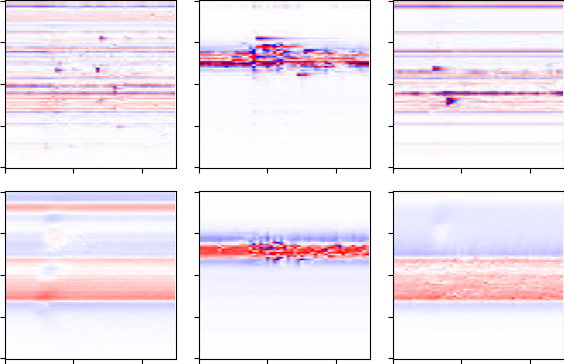

In [15]:
correlationsOrig500, distancesOrig500 = producePlotAndCorrelation(icsd_high_original_500,ocsd_original_500,icsd_L4_original_500,ocsd_l4_500,icsd_L5_original_500,ocsd_l5_500)


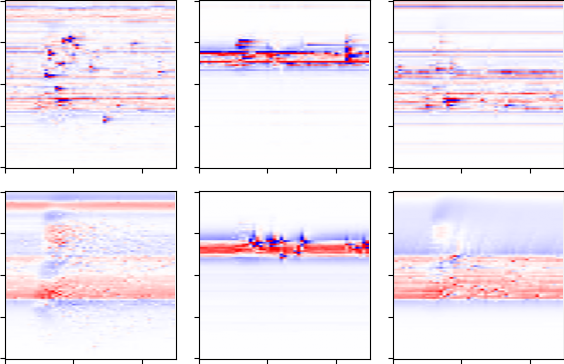

In [16]:
correlationsNoRecurrent500, distancesNoRecurrent500 = producePlotAndCorrelation(icsd_high_noRecurrent_500,ocsd_noRecurrent_500,icsd_L4_noRecurrent_500,ocsd_noRecurrent_l4_500,icsd_L5_noRecurrent_500,ocsd_noRecurrent_l5_500)


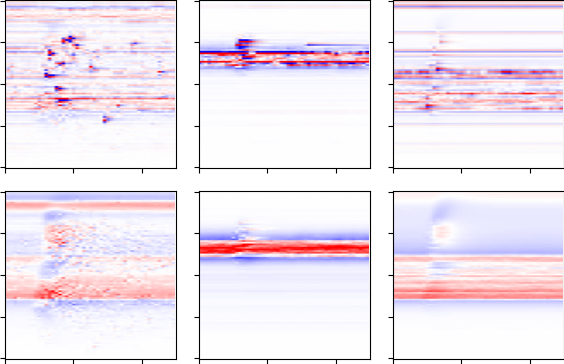

In [17]:
correlationsNoActive500, distancesNoActive500 = producePlotAndCorrelation(icsd_high_NoActive_500,ocsd_noActive_500,icsd_L4_NoActive_500,ocsd_noActive_l4_500,icsd_L5_NoActive_500,ocsd_noActive_l5_500)


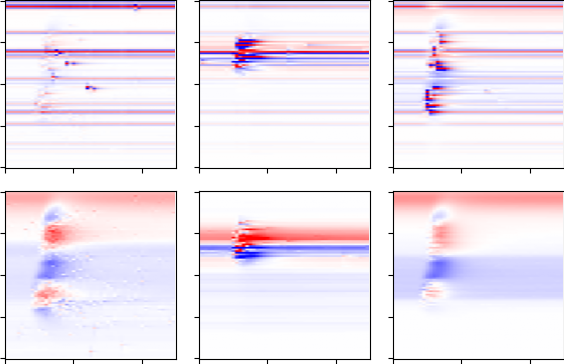

In [18]:
correlationsNoNoise500, distancesNoNoise500 = producePlotAndCorrelation(icsd_high_NoNoise_500,ocsd_noNoise_500,icsd_L4_NoNoise_500,ocsd_noNoise_l4_500,icsd_L5_NoNoise_500,ocsd_noNoise_l5_500)


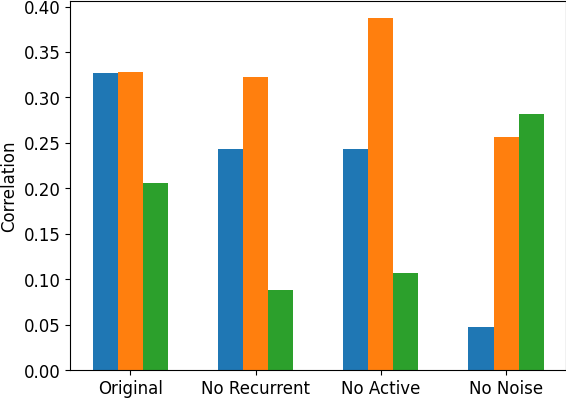

In [28]:
bar_width = 0.2
x = np.arange(4)

fig, ax = plt.subplots()

for i in range(3):
    ax.bar(x + i*bar_width, correlations500[:, i], width=bar_width)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(['Original','No Recurrent','No Active','No Noise'])

plt.ylabel('Correlation')

plt.show()

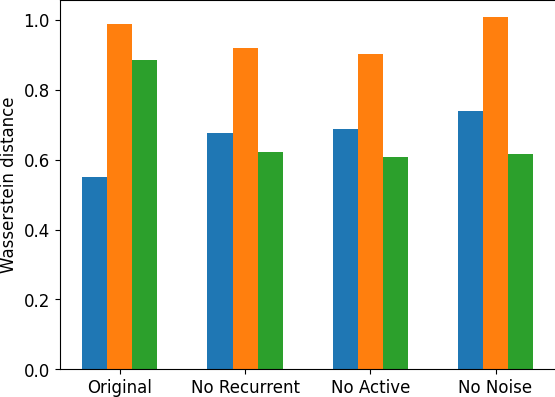

In [36]:
bar_width = 0.2
x = np.arange(4)

fig, ax = plt.subplots()

for i in range(3):
    ax.bar(x + i*bar_width, distances20[:, i], width=bar_width)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(['Original','No Recurrent','No Active','No Noise'])

plt.ylabel('Wasserstein distance')

plt.show()

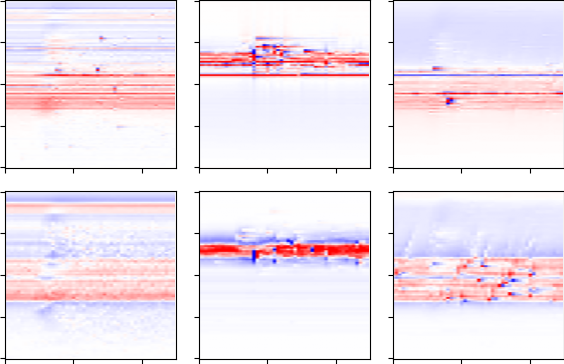

In [23]:
correlationsOrig100, distancesOrig100 = producePlotAndCorrelation(icsd_high_original_100,ocsd_original_100,icsd_L4_original_100,ocsd_l4_100,icsd_L5_original_100,ocsd_l5_100)


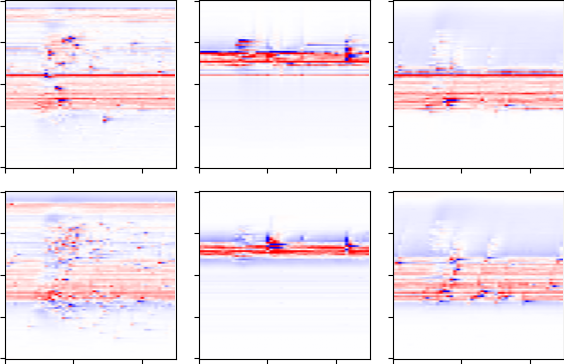

In [24]:
correlationsNoRecurrent100, distancesNoRecurrent100 = producePlotAndCorrelation(icsd_high_noRecurrent_100,ocsd_noRecurrent_100,icsd_L4_noRecurrent_100,ocsd_noRecurrent_l4_100,icsd_L5_noRecurrent_100,ocsd_noRecurrent_l5_100)


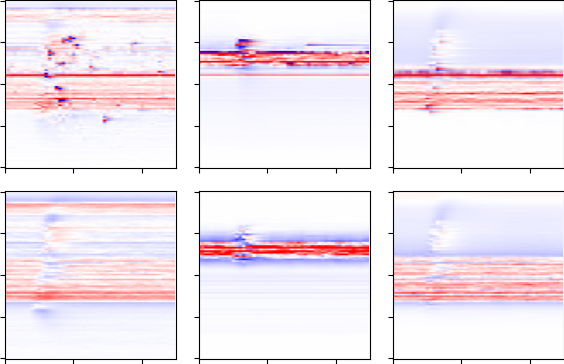

In [25]:
correlationsNoActive100, distancesNoActive100 = producePlotAndCorrelation(icsd_high_NoActive_100,ocsd_noActive_100,icsd_L4_NoActive_100,ocsd_noActive_l4_100,icsd_L5_NoActive_100,ocsd_noActive_l5_100)


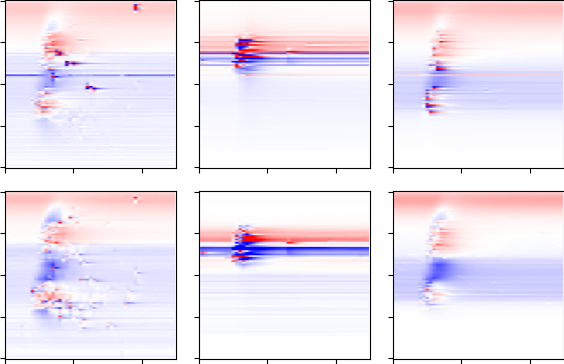

In [26]:
correlationsNoNoise100, distancesNoNoise100 = producePlotAndCorrelation(icsd_high_NoNoise_100,ocsd_noNoise_100,icsd_L4_NoNoise_100,ocsd_noNoise_l4_100,icsd_L5_NoNoise_100,ocsd_noNoise_l5_100)


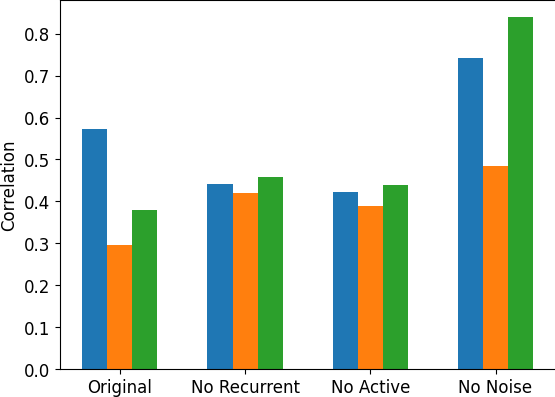

In [29]:
bar_width = 0.2
x = np.arange(4)

fig, ax = plt.subplots()

for i in range(3):
    ax.bar(x + i*bar_width, correlations100[:, i], width=bar_width)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(['Original','No Recurrent','No Active','No Noise'])

plt.ylabel('Correlation')

plt.show()

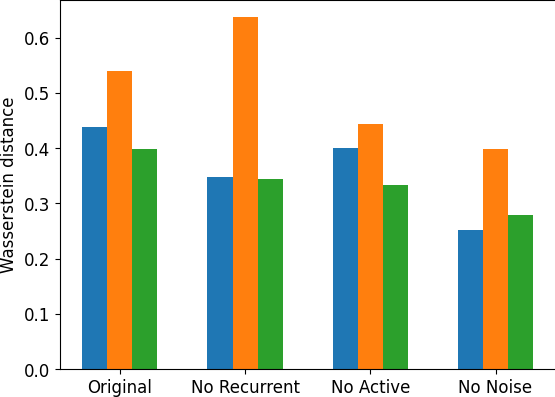

In [30]:
bar_width = 0.2
x = np.arange(4)

fig, ax = plt.subplots()

for i in range(3):
    ax.bar(x + i*bar_width, distances100[:, i], width=bar_width)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(['Original','No Recurrent','No Active','No Noise'])

plt.ylabel('Wasserstein distance')

plt.show()

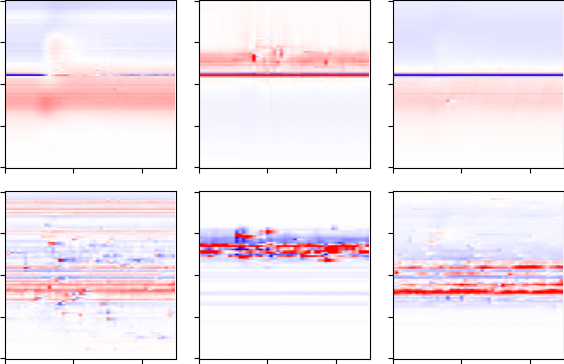

In [19]:
correlationsOrig20, distancesOrig20 = producePlotAndCorrelation(icsd_high_original_20,ocsd_original_20,icsd_L4_original_20,ocsd_l4_20,icsd_L5_original_20,ocsd_l5_20)


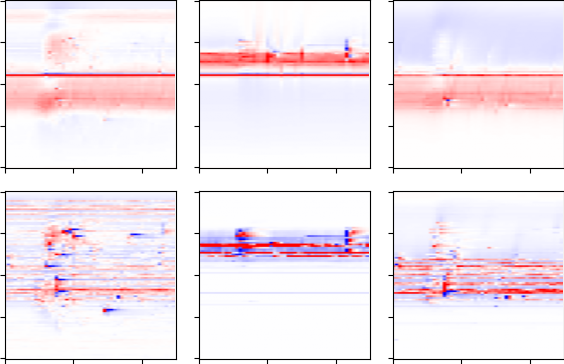

In [20]:
correlationsNoRecurrent20, distancesNoRecurrent20 = producePlotAndCorrelation(icsd_high_noRecurrent_20,ocsd_noRecurrent_20,icsd_L4_noRecurrent_20,ocsd_noRecurrent_l4_20,icsd_L5_noRecurrent_20,ocsd_noRecurrent_l5_20)


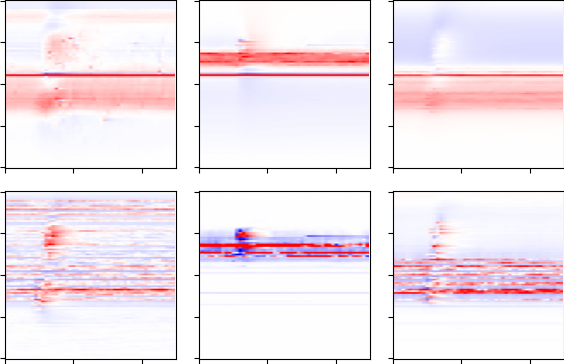

In [21]:
correlationsNoActive20, distancesNoActive20 = producePlotAndCorrelation(icsd_high_NoActive_20,ocsd_noActive_20,icsd_L4_NoActive_20,ocsd_noActive_l4_20,icsd_L5_NoActive_20,ocsd_noActive_l5_20)



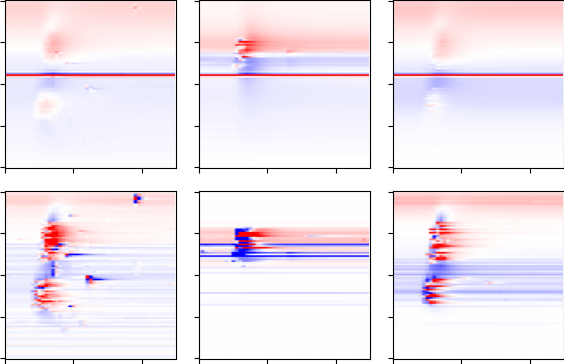

In [22]:
correlationsNoNoise20, distancesNoNoise20 = producePlotAndCorrelation(icsd_high_NoNoise_20,ocsd_noNoise_20,icsd_L4_NoNoise_20,ocsd_noNoise_l4_20,icsd_L5_NoNoise_20,ocsd_noNoise_l5_20)


In [27]:
correlations500 = np.array([correlationsOrig500, correlationsNoRecurrent500, correlationsNoActive500, correlationsNoNoise500])
correlations100 = np.array([correlationsOrig100, correlationsNoRecurrent100, correlationsNoActive100, correlationsNoNoise100])
correlations20 = np.array([correlationsOrig20, correlationsNoRecurrent20, correlationsNoActive20, correlationsNoNoise20])

distances500 = np.array([distancesOrig500, distancesNoRecurrent500, distancesNoActive500, distancesNoNoise500])
distances100 = np.array([distancesOrig100, distancesNoRecurrent100, distancesNoActive100, distancesNoNoise100])
distances20 = np.array([distancesOrig20, distancesNoRecurrent20, distancesNoActive20, distancesNoNoise20])


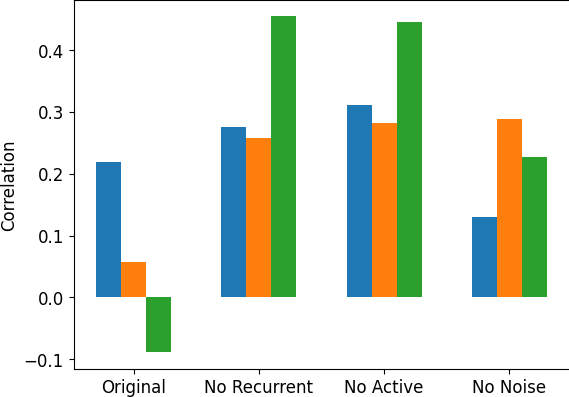

In [35]:
bar_width = 0.2
x = np.arange(4)

fig, ax = plt.subplots()

for i in range(3):
    ax.bar(x + i*bar_width, correlations20[:, i], width=bar_width)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(['Original','No Recurrent','No Active','No Noise'])

plt.ylabel('Correlation')

plt.show()

In [28]:
for f in correlations500:
    print(f)

[np.float64(0.2752671015621234), np.float64(0.3284058440580628), np.float64(0.20644730077464055)]
[np.float64(0.24354113253593698), np.float64(0.32260586930556967), np.float64(0.0880944185359527)]
[np.float64(0.24354113253593698), np.float64(0.38710142215979104), np.float64(0.10673677708919849)]
[np.float64(0.047728169403724416), np.float64(0.25602402211449593), np.float64(0.2814694035179071)]


In [29]:
for f in correlations20:
    print(f)

[np.float64(0.21891397057664397), np.float64(0.05664435362826472), np.float64(-0.08915088554564925)]
[np.float64(0.27614694674365237), np.float64(0.25849949703259484), np.float64(0.4547790912642513)]
[np.float64(0.31219379218221016), np.float64(0.2826921516221745), np.float64(0.4461597521575362)]
[np.float64(0.1301064764045144), np.float64(0.2881474621050847), np.float64(0.22661532839109277)]


In [30]:
for f in distances20:
    print(f)

[np.float64(0.5488986452327381), np.float64(0.9883529054511604), np.float64(0.8842026219278981)]
[np.float64(0.6761325566431411), np.float64(0.9194639740296217), np.float64(0.6229058859282423)]
[np.float64(0.6864241820119155), np.float64(0.9037705480001875), np.float64(0.608288553514378)]
[np.float64(0.7389762257339878), np.float64(1.007470140901826), np.float64(0.6167189239219502)]


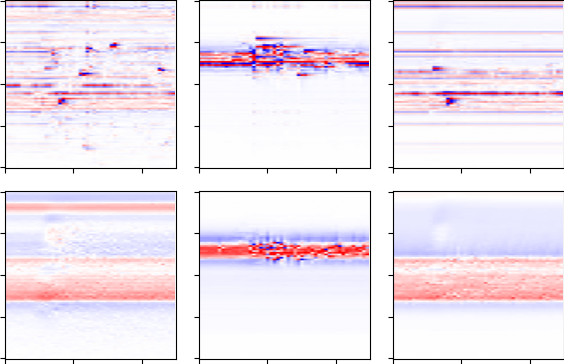

In [92]:
fig, axes = plt.subplots(2,3,figsize=(6,4))

plotFig(axes[0][0],icsd_high_original_500.get_csd())
plotFig(axes[1][0],ocsd_original_500.T)

plotFig(axes[0][1],icsd_L4_original_500.get_csd())
plotFig(axes[1][1],ocsd_l4_500.T)

plotFig(axes[0][2],icsd_L5_original_500.get_csd())
plotFig(axes[1][2],ocsd_l5_500.T)



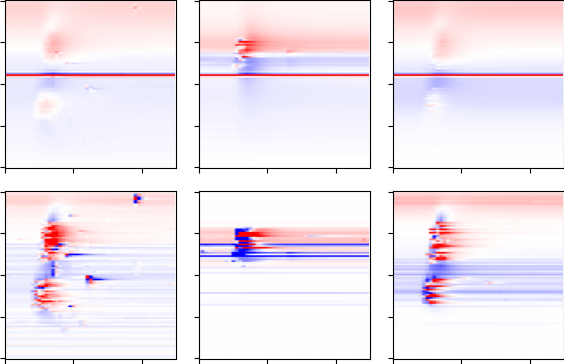

In [78]:
fig, axes = plt.subplots(2,3,figsize=(6,4))

plotFig(axes[0][0],icsd_high_NoNoise_20.get_csd())
plotFig(axes[1][0],ocsd_noNoise_20.T)

plotFig(axes[0][1],icsd_L4_NoNoise_20.get_csd())
plotFig(axes[1][1],ocsd_noNoise_l4_20.T)

plotFig(axes[0][2],icsd_L5_NoNoise_20.get_csd())
plotFig(axes[1][2],ocsd_noNoise_l5_20.T)

In [114]:
ocsd_noNoise_l4_20.T.shape

(101, 50)

In [84]:
getMeanCorrelation(icsd_L4_NoNoise_20,ocsd_noNoise_l4_20)

np.float64(0.6440737308366242)

In [85]:
getMeanCorrelation(icsd_L5_NoNoise_20,ocsd_noNoise_l5_20)

np.float64(0.6133076645043712)

In [115]:
getMeanCorrelation(icsd_high_NoNoise_500,ocsd_noNoise_500)

np.float64(0.5238640841478382)

In [20]:
### Calculates correlations between iCSD and oCSD for all electrode spacings

correlations_high_stim = []
correlations_low_stim = []
correlations_low_half_stim = []
correlations_low_quarter_stim = []

for i in np.arange(1500,1550):
    correlations_high_stim.append(np.corrcoef(icsd_high.get_csd()[:,i],objective_disk_full_highRes.T[:,i])[0,1])
    correlations_low_stim.append(np.corrcoef(icsd_low.get_csd()[:,i],objective_disk_full_lowRes.T[:,i])[0,1])
    correlations_low_half_stim.append(np.corrcoef(icsd_low_half.get_csd()[:,i],objective_disk_half_lowRes.T[:,i])[0,1])
    correlations_low_quarter_stim.append(np.corrcoef(icsd_low_quarter.get_csd()[:,i],objective_disk_quarter_lowRes.T[:,i])[0,1])


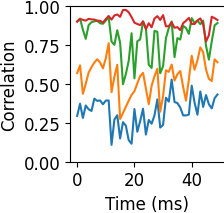

In [21]:
### Plots Figure 2b

plt.figure(figsize=(2.5,2.5))
plt.plot(correlations_high_stim,c='C0')
plt.plot(correlations_low_stim,c='C1')
plt.plot(correlations_low_half_stim,c='C2')
plt.plot(correlations_low_quarter_stim,c='C3')

plt.ylim([0,1])
plt.xlabel('Time (ms)')
plt.ylabel('Correlation')
plt.tight_layout()
# plt.savefig('figures/correlations.png',dpi=300)

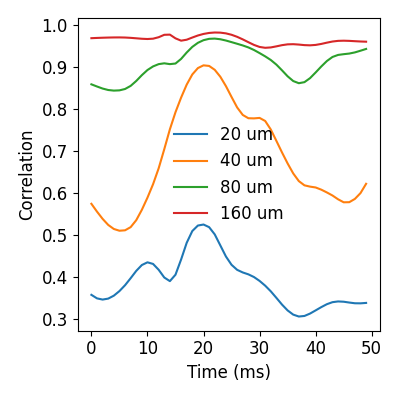

In [25]:
### Plots Figure 2b again, but with a legend

plt.figure(figsize=(4,4))
plt.plot(correlations_high_stim,c='C0',linestyle=None)
plt.plot(correlations_low_stim,c='C1',linestyle=None)
plt.plot(correlations_low_half_stim,c='C2',linestyle=None)
plt.plot(correlations_low_quarter_stim,c='C3',linestyle=None)

# plt.plot(correlations_high_rest,'--',c='C0')
# plt.plot(correlations_low_rest,'--',c='C1')
# plt.plot(correlations_low_half_rest,'--',c='C2')
# plt.plot(correlations_low_quarter_rest,'--',c='C3')

plt.legend(['20 um', '40 um','80 um','160 um'],framealpha=0)
plt.xlabel('Time (ms)')
plt.ylabel('Correlation')
plt.tight_layout()
plt.savefig('figures/correlations_legend.png',dpi=300)